In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#____________________________ part a ______________________________#
import pandas as pd

laptop_data = pd.read_csv('laptop_price.csv', encoding='latin-1')
laptop_data.sample(10)
#laptop_data.info()
#laptop_data.shape
#laptop_data.describe()


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1092,1107,Asus,Rog GL702VM-GC354T,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.7kg,1599.00
1243,1261,Dell,Inspiron 7779,2 in 1 Convertible,17.3,Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,16GB,512GB SSD,Nvidia GeForce 940MX,Windows 10,2.77kg,1799.00
989,1003,Dell,Latitude 5480,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,128GB SSD,Intel HD Graphics 620,Windows 10,1.6kg,1119.00
1283,1301,Asus,X556UJ-XO044T (i7-6500U/4GB/500GB/GeForce,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.2kg,720.32
1240,1258,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,597.57
1170,1188,HP,250 G5,Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.96kg,679.00
360,366,HP,250 G6,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 10,1.86kg,439.00
983,997,Fujitsu,LifeBook A556,Notebook,15.6,1366x768,Intel Core i5 6200U 2.3GHz,4GB,256GB SSD,Intel HD Graphics 520,Windows 10,2.3kg,649.00
1071,1086,HP,ProBook 650,Notebook,15.6,1366x768,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 10,2.31kg,1199.00
1258,1276,Lenovo,B51-80 (i7-6500U/8GB/1008GB/Radeon,Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8GB,1.0TB Hybrid,AMD Radeon R5 M330,Windows 7,2.32kg,895.00


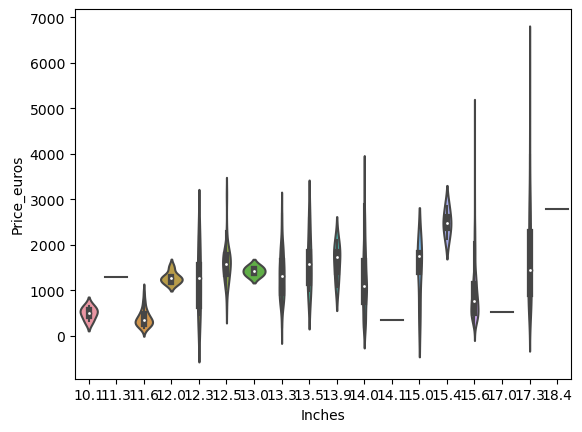

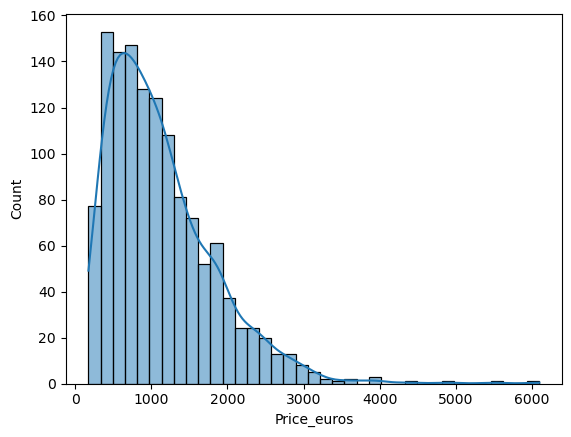

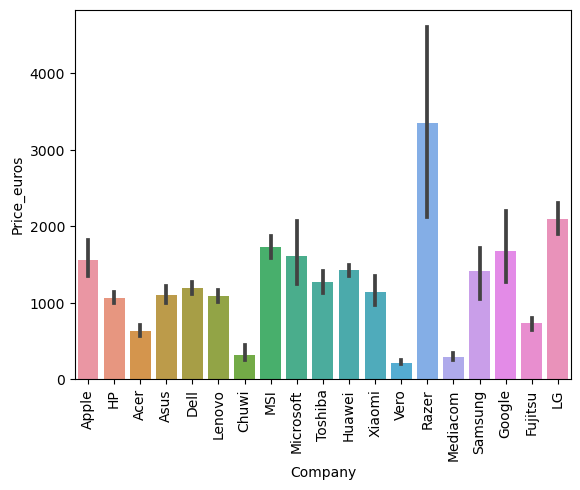

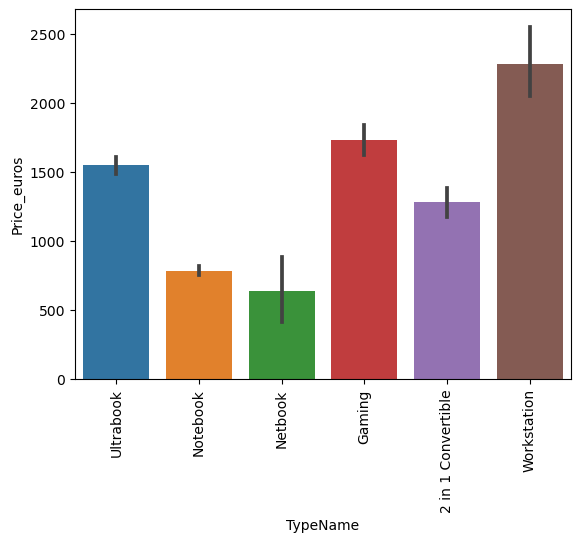

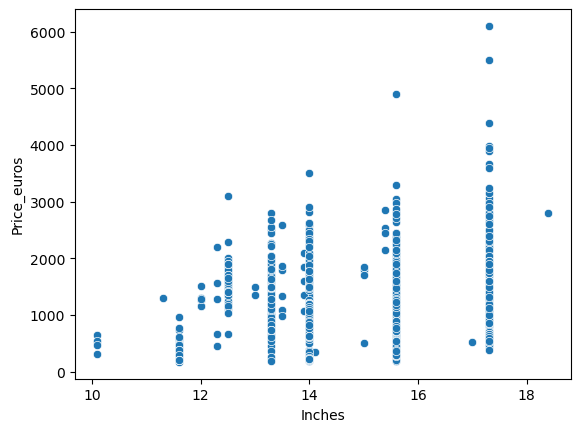

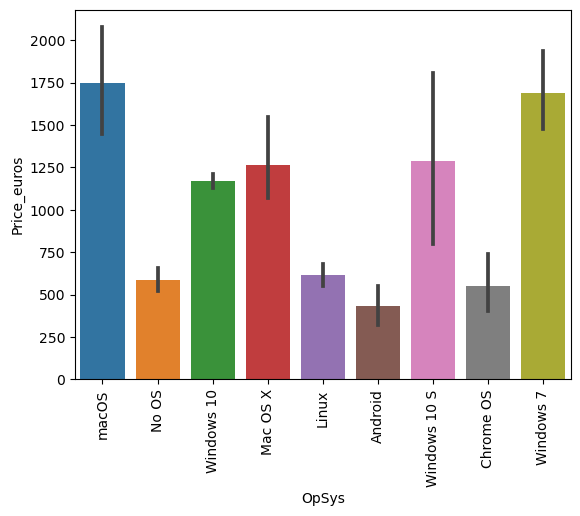

In [3]:
#____________________________ part b ______________________________#
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

plot1=sns.violinplot(y='Price_euros',x='Inches',data=laptop_data,inner='box')
plt.show()
_=plt.figure()
plot2=sns.histplot(laptop_data['Price_euros'],kde=True)
plt.show()
_=plt.figure()
plot3=sns.barplot(x=laptop_data['Company'], y=laptop_data['Price_euros'])
plot3_xticks=plt.xticks(rotation="vertical")
plt.show()
_=plt.figure()
plot4=sns.barplot(x=laptop_data['TypeName'], y=laptop_data['Price_euros'])
plot4_xticks=plt.xticks(rotation="vertical")
plt.show()
_=plt.figure()
plot5=sns.scatterplot(x=laptop_data['Inches'],y=laptop_data['Price_euros'])
plt.show()
_=plt.figure()
plot6=sns.barplot(x=laptop_data['OpSys'], y=laptop_data['Price_euros'])
plot6_xticks=plt.xticks(rotation="vertical")
plt.show()


In [4]:
#____________________________ part c ______________________________#

#____________________________ 1 Touch screen information 
laptop_data['Touchscreen'] = laptop_data['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
#sns.countplot(laptop_data['Touchscreen'])
#sns.barplot(x=laptop_data['Touchscreen'],y=laptop_data['Price_euros'])
#laptop_data.sample(10)
#____________________________ 2 IPS Channel presence information 
laptop_data['Ips'] = laptop_data['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
#sns.barplot(x=laptop_data['Ips'],y=laptop_data['Price_euros'])
#laptop_data.sample(10)
#____________________________ 3 X-axis and Y-axis screen resolution 
laptop_data['X_res'] = laptop_data['ScreenResolution'].apply(lambda x: x.split(" ")[-1].split("x")[0])
laptop_data['Y_res'] = laptop_data['ScreenResolution'].apply(lambda x: x.split(" ")[-1].split("x")[1])
laptop_data['X_res'] = laptop_data['X_res'].astype('int')
laptop_data['Y_res'] = laptop_data['Y_res'].astype('int')
#____________________________ 4 Replacing inches, X and Y resolution to PPI 
laptop_data['ppi'] = (((laptop_data['X_res']**2) + (laptop_data['Y_res']**2))**0.5/laptop_data['Inches']).astype('float')
laptop_data.corr(numeric_only=True)['Price_euros'].sort_values(ascending=False)
laptop_data.drop(columns = ['ScreenResolution', 'Inches','X_res','Y_res'], inplace=True)
#laptop_data.sample(10)
#____________________________ 5 CPU column 
def fetch_processor(x):
  cpu_name = " ".join(x.split()[0:3])
  if cpu_name == 'Intel Core i7' or cpu_name == 'Intel Core i5' or cpu_name == 'Intel Core i3':
    return cpu_name
  elif cpu_name.split()[0] == 'Intel':
    return 'Other Intel Processor'
  else:
    return 'AMD Processor'
laptop_data['Cpu_brand'] = laptop_data['Cpu'].apply(lambda x: fetch_processor(x))
#laptop_data.sample(10)
#plot7=sns.barplot(x=laptop_data['Cpu_brand'],y=laptop_data['Price_euros'])
#plot7_xticks=plt.xticks(rotation='vertical')
#sns.barplot(x=laptop_data['Ram'], y=laptop_data['Price_euros'])
#____________________________ 6 Memory column 
laptop_data['Memory'] = laptop_data['Memory'].astype(str).replace('.0', '', regex=True)
laptop_data["Memory"] = laptop_data["Memory"].str.replace('GB', '')
laptop_data["Memory"] = laptop_data["Memory"].str.replace('TB', '000')
new_mem = laptop_data["Memory"].str.split("+", n = 1, expand = True)
laptop_data["first"]= new_mem[0]
laptop_data["first"]=laptop_data["first"].str.strip()
laptop_data["second"]= new_mem[1]
#laptop_data.sample(20)
laptop_data["Layer1HDD"] = laptop_data["first"].apply(lambda x: 1 if "HDD" in x else 0)
laptop_data["Layer1SSD"] = laptop_data["first"].apply(lambda x: 1 if "SSD" in x else 0)
laptop_data["Layer1Hybrid"] = laptop_data["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
laptop_data["Layer1Flash_Storage"] = laptop_data["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)
laptop_data['first'] = laptop_data['first'].str.replace(r'\D+', '', regex=True).astype(int)
#laptop_data.sample(10)
laptop_data["second"].fillna("0", inplace = True)
laptop_data["Layer2HDD"] = laptop_data["second"].apply(lambda x: 1 if "HDD" in x else 0)
laptop_data["Layer2SSD"] = laptop_data["second"].apply(lambda x: 1 if "SSD" in x else 0)
laptop_data["Layer2Hybrid"] = laptop_data["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
laptop_data["Layer2Flash_Storage"] = laptop_data["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)
#laptop_data.sample(10)
laptop_data["Layer2HDD"] = laptop_data["second"].apply(lambda x: 1 if "HDD" in x else 0)
laptop_data["Layer2SSD"] = laptop_data["second"].apply(lambda x: 1 if "SSD" in x else 0)
laptop_data["Layer2Hybrid"] = laptop_data["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
laptop_data["Layer2Flash_Storage"] = laptop_data["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)
#laptop_data.sample(10)
laptop_data['second'] = laptop_data['second'].str.replace(r'\D+', '', regex=True).astype(int)
#laptop_data.sample(20)
laptop_data["HDD"]=(laptop_data["first"]*laptop_data["Layer1HDD"]+laptop_data["second"]*laptop_data["Layer2HDD"])
laptop_data["SSD"]=(laptop_data["first"]*laptop_data["Layer1SSD"]+laptop_data["second"]*laptop_data["Layer2SSD"])
laptop_data["Hybrid"]=(laptop_data["first"]*laptop_data["Layer1Hybrid"]+laptop_data["second"]*laptop_data["Layer2Hybrid"])
laptop_data["Flash_Storage"]=(laptop_data["first"]*laptop_data["Layer1Flash_Storage"]+
                              laptop_data["second"]*laptop_data["Layer2Flash_Storage"])
laptop_data.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)
#laptop_data.sample(20)
laptop_data.corr(numeric_only=True)['Price_euros'].sort_values(ascending=False)
laptop_data.drop(columns=['Hybrid','Memory','Cpu','laptop_ID','Product'],inplace=True)

#____________________________ 7 Ram and Weight 
laptop_data['Ram'] = laptop_data['Ram'].str.replace("GB", "").astype('int32')
laptop_data['Weight'] = laptop_data['Weight'].str.replace("kg", "").astype('float32')
laptop_data.drop(columns=['Weight'],inplace=True)
#laptop_data.sample(20)
#____________________________ 8 GPU 
laptop_data['Gpu_brand'] = laptop_data['Gpu'].apply(lambda x:x.split()[0])
#laptop_data['Gpu_brand'][3]
#laptop_data.shape
gpu_list={}
for brand in laptop_data['Gpu_brand']:
    if brand in gpu_list:
        gpu_list[brand]+=1
    else:
        gpu_list[brand]=1
print(gpu_list)
laptop_data= laptop_data[laptop_data['Gpu_brand'] != 'ARM']
laptop_data.drop(columns=['Gpu'],inplace=True)
#laptop_data.sample(20)

#____________________________ 9 Operating System Column 
def OS(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'
laptop_data['os'] = laptop_data['OpSys'].apply(OS)
laptop_data.drop(columns=['OpSys'],inplace=True)


Price_euros    1.000000
X_res          0.556529
Y_res          0.552809
ppi            0.473487
Ips            0.252208
Touchscreen    0.191226
Inches         0.068197
laptop_ID      0.067830
Name: Price_euros, dtype: float64

Price_euros      1.000000
SSD              0.666734
ppi              0.473487
Ips              0.252208
Touchscreen      0.191226
laptop_ID        0.067830
Hybrid           0.008811
HDD             -0.026830
Flash_Storage   -0.040511
Name: Price_euros, dtype: float64

{'Intel': 722, 'AMD': 180, 'Nvidia': 400, 'ARM': 1}


{'Netbook': 25, 'Workstation': 29, '2 in 1 Convertible': 120, 'Ultrabook': 196, 'Gaming': 205, 'Notebook': 727}


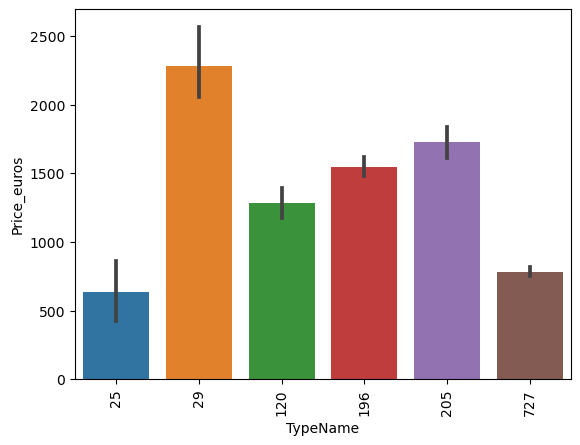

{'AMD Processor': 62, 'Intel Core i3': 136, 'Other Intel Processor': 154, 'Intel Core i5': 423, 'Intel Core i7': 527}


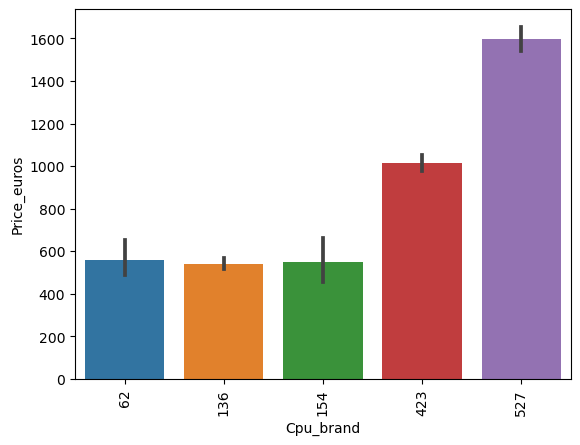

{'AMD': 180, 'Nvidia': 400, 'Intel': 722}


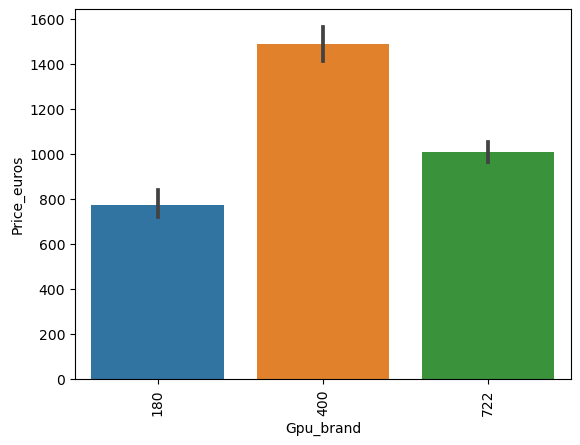

{'Mac': 21, 'Others/No OS/Linux': 156, 'Windows': 1125}


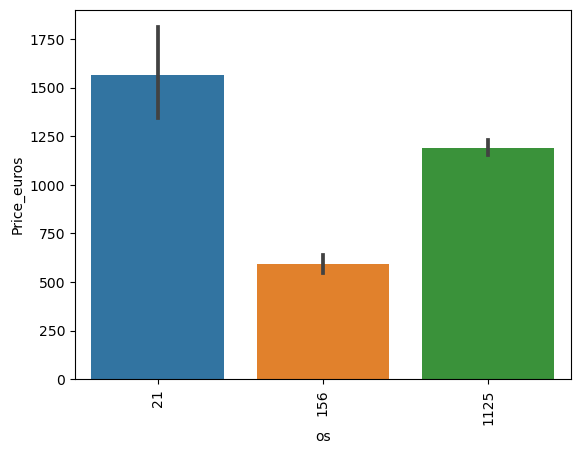

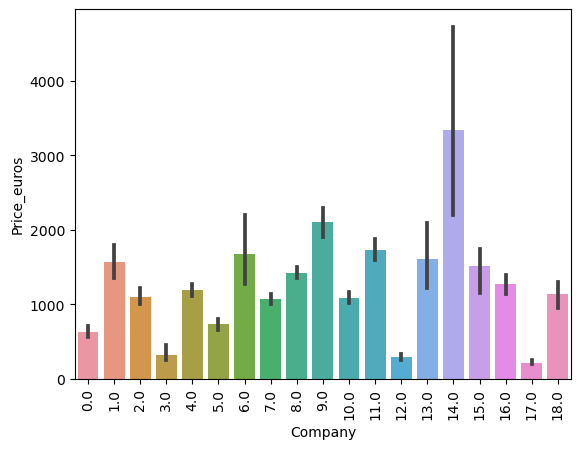

Price_euros      1.000000
Ram              0.742905
SSD              0.666593
Cpu_brand        0.574814
ppi              0.475368
Ips              0.253320
os               0.228744
Touchscreen      0.192917
Company          0.141705
HDD             -0.027189
Flash_Storage   -0.040067
Gpu_brand       -0.070204
TypeName        -0.532814
Name: Price_euros, dtype: float64

training, test and validation values' shape is (936, 12), (261, 12) and (105, 12), respctively.
training, test and validation target's shape is (936,), (261,) and (105,), respctively.


In [5]:
#____________________________ part d ______________________________#

#____________________________ encoding
from sklearn.preprocessing import OrdinalEncoder

def quality_item_encoder(data,col):
    items={}
    for case in data[col]:
        if case in items:
            items[case]+=1
        else:
            items[case]=1
    items={value:key for key,value in items.items()}
    key_list=sorted(items)
    sorted_items={}
    for key in key_list:
        sorted_items[key]=items[key]
    item_num={value:key for key,value in sorted_items.items()}
    print(item_num)
    for key in list(item_num.keys()):
        data[col] = data[col].replace([key], item_num[key])

#laptop_data["Company"] = laptop_data["Company"].replace('Razer', laptop_data['Company'].value_counts()['Razer'])
quality_item_encoder(laptop_data,'TypeName')
_=plt.figure()
_=sns.barplot(x=laptop_data['TypeName'],y=laptop_data['Price_euros'])
_=plt.xticks(rotation='vertical')
_=plt.show()
quality_item_encoder(laptop_data,'Cpu_brand')
_=plt.figure()
_=sns.barplot(x=laptop_data['Cpu_brand'],y=laptop_data['Price_euros'])
_=plt.xticks(rotation='vertical')
_=plt.show()
quality_item_encoder(laptop_data,'Gpu_brand')
_=plt.figure()
_=sns.barplot(x=laptop_data['Gpu_brand'],y=laptop_data['Price_euros'])
_=plt.xticks(rotation='vertical')
_=plt.show()
quality_item_encoder(laptop_data,'os')
_=plt.figure()
_=sns.barplot(x=laptop_data['os'],y=laptop_data['Price_euros'])
_=plt.xticks(rotation='vertical')
_=plt.show()
enc1=OrdinalEncoder()
laptop_data[['Company']] = enc1.fit_transform(laptop_data[['Company']])
_=plt.figure()
_=sns.barplot(x=laptop_data['Company'],y=laptop_data['Price_euros'])
_=plt.xticks(rotation='vertical')
_=plt.show()
laptop_data=laptop_data.astype('float64')
laptop_data.corr(numeric_only=True)['Price_euros'].sort_values(ascending=False)
#laptop_data.sample(20)
#laptop_data['Price_euros'].max()
#laptop_data.head()
#laptop_data['Price_euros'][1]
#____________________________ scaling 
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
col_list=[]
for col in list(laptop_data.columns):
    if col!='Price_euros':
        col_list.append(col)
#print(col_list)
laptop_data[col_list] = scaler.fit_transform(laptop_data[col_list])
#laptop_data.sample(20)
#____________________________ train/test/validation split 
from sklearn.model_selection import train_test_split 

laptop_data_price=laptop_data['Price_euros']
laptop_data_vals=laptop_data[col_list]
#laptop_data_price.head()
#laptop_data_vals.head()
X_train, X_test, y_train, y_test=train_test_split(laptop_data_vals, laptop_data_price, test_size=0.2, random_state=8)
X_train, X_val, y_train, y_val=train_test_split(X_train, y_train, test_size=0.1, random_state=8)
print("training, test and validation values' shape is {}, {} and {}, respctively.".format(X_train.shape,X_test.shape,X_val.shape))
print("training, test and validation target's shape is {}, {} and {}, respctively.".format(y_train.shape,y_test.shape,y_val.shape))


Degree: 1, MSE: 179784.14
Degree: 2, MSE: 141428.57
Degree: 3, MSE: 1953691618400238023993196544.00
Degree: 4, MSE: 576890710979673718784.00
Degree: 5, MSE: 183795271965654417408.00
Degree: 6, MSE: 1034340740035518315131568128.00
Degree: 7, MSE: 20315967432831069447432175616.00
Degree: 8, MSE: 8902288968416345368274403328.00


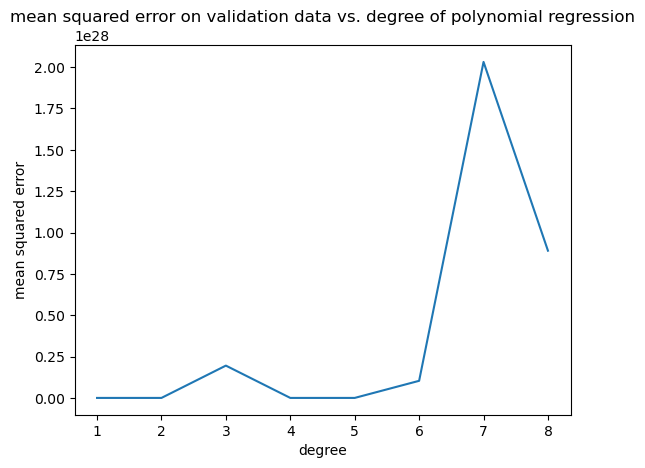

In [6]:
#____________________________ part e ______________________________#
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

def poly_reg(degree, training_data, validation_data, feature_list, target_list):
    model=LinearRegression()
    cv=KFold(n_splits=10, random_state=8, shuffle=True)
    mse_scores=[]
    X=training_data[feature_list]
    y=training_data[target_list]
    X_val=validation_data[feature_list]
    y_val=validation_data[target_list]
    poly_feature=PolynomialFeatures(degree=degree,include_bias=False)
    for train_index, test_index in cv.split(X):
        X_train, y_train=X.iloc[train_index], y.iloc[train_index]
        X_poly=poly_feature.fit_transform(X_train)
        model.fit(X_poly,y_train)
        X_val_poly=poly_feature.transform(X_val)
        y_pred=model.predict(X_val_poly)
        mse_scores.append(mean_squared_error(y_val,y_pred))
    return np.mean(mse_scores)

training_set=pd.concat([X_train,y_train],axis=1)
validation_set=pd.concat([X_val,y_val],axis=1)
test_set=pd.concat([X_test,y_test],axis=1)
degree_list=range(1,9)
mse_list=[poly_reg(degree=deg, training_data=training_set, validation_data=validation_set, feature_list=col_list, target_list='Price_euros') for deg in degree_list]
for degree, mse in zip(degree_list,mse_list):
    print(f"Degree: {degree}, MSE: {mse:.2f}")
_=plt.figure()
_=plt.plot(degree_list, mse_list)
_=plt.xlabel("degree")
_=plt.ylabel("mean squared error")
_=plt.title("mean squared error on validation data vs. degree of polynomial regression")
_=plt.show()


In [7]:
#____________________________ part f ______________________________#
best_degree=mse_list.index(min(mse_list))+1
poly_transformer=PolynomialFeatures(degree=best_degree,include_bias=False)
X_poly=poly_transformer.fit_transform(training_set[col_list])
lin_reg_model=LinearRegression()
lin_reg_model.fit(X_poly,training_set['Price_euros'])
X_test_poly=poly_transformer.transform(test_set[col_list])
y_pred=lin_reg_model.predict(X_test_poly)
mse=mean_squared_error(test_set['Price_euros'],y_pred)
r2=lin_reg_model.score(X_test_poly,test_set['Price_euros'])
print(f"final model (degree={best_degree}) - mse: {mse:.2f}, R2: {r2:.2f}")


LinearRegression()

final model (degree=2) - mse: 132941.43, R2: 0.73
